In [1]:
import sys
from pathlib import Path

HERE = Path.cwd().resolve()
up1_path = str((HERE / "..").resolve())
up2_path = str((HERE / ".." / "..").resolve())
for pathstr in [up1_path, up2_path]:
  if pathstr not in sys.path:
      sys.path.insert(0, pathstr)

from helpers import *
import numpy as np
from convergence_problem import ConvergenceProblemE

In [2]:
# code to generate data (commented out) + variable definitions
file1 = str((HERE / "data" / "predetermined-2.pkl").resolve())

big_nmk, nmk_max = 200, 150
heaving, NMK, rho = [0, 0, 1], [big_nmk] * 4, 1023
region = 2

m0h_base = 30
h_base = 20
hmd0h_base = 0.250
hmd1h_base = 0.375
hmd2h_base = 0.500
hmdr_base = 20
total_rad_base = 7

m0h_list = [0.01 * i for i in range(1, 10)] + [0.1 * i for i in range(1, 10)] + [1 * i for i in range(1, 10)] + [10 * i for i in range(1, 10)]
hmd01h_list = [0.05 * i + 0.001 for i in range(3, 20)]
hmd2h_list = [0.05 * i for i in range(3, 19)] + [0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99]
hmdr_list = [i for i in range(2, 31)]
total_rad_list = [0.6, 0.7, 0.8, 0.9] + [0.5 * i for i in range(2, 21)]
m0h_for_rad_list = [0.1, 0.3, 1, 3, 10, 30]
h_for_rad_list_2 = [5, 10, 15]


def solve_and_store(h, d, a, heaving, NMK, m0s, rho, nmk_max):
  info1 = {"h" : h,
          "d" : d,
          "a" : a,
          "m0s" : m0s}
  prob = ConvergenceProblemE(h, d, a, heaving, NMK, m0s[0], rho)
  results = prob.convergence_study_over_m0s(nmk_max, m0s, region = 2)
  info2 = {m0 : {"am" : results[m0]["am2"],
                 "dp" : results[m0]["dp2"],
                 "ams" : results[m0]["ams2"],
                 "dps" : results[m0]["dps2"]} for m0 in m0s}
  return merge_dicts(info1, info2)

def generate_geom(h, m0h, hmd0h, hmd1h, hmd2h, hmdr, total_rad):
  m0 = m0h/h
  hmds = [h * hmdh for hmdh in [hmd0h, hmd1h, hmd2h]]
  d = [h - hmd for hmd in hmds]
  radwidth2 = (h-d[2]) / hmdr
  radwidth0 = (total_rad - radwidth2)/2
  radwidth1 = radwidth0
  radwidths = [radwidth0, radwidth1, radwidth2]
  a = [sum(radwidths[:i+1]) for i in range(3)]
  for i in range(3):
    assert radwidths[i] > 0
    assert d[i] > 0
    assert hmds[i] >= 0.9 * radwidths[i] # This is for the chosen nmk_max.
  return d, a, m0

# all_prob_sets = []

# prob_set = []
# d, a, m0 = generate_geom(h_base, m0h_base, hmd0h_base, hmd1h_base, hmd2h_base, hmdr_base, total_rad_base)
# prob_set.append(solve_and_store(h_base, d, a, heaving, NMK, [m0], rho, nmk_max))
# all_prob_sets.append(prob_set)
# update_data_file(all_prob_sets, file1)
# print("Finished base.")

# # m0h
# prob_set = []
# for m0h in m0h_list:
#   d, a, m0 = generate_geom(h_base, m0h, hmd0h_base, hmd1h_base, hmd2h_base, hmdr_base, total_rad_base)
#   prob_set.append(solve_and_store(h_base, d, a, heaving, NMK, [m0], rho, nmk_max))
# all_prob_sets.append(prob_set)
# update_data_file(all_prob_sets, file1)
# print("Finished m0hs.")

# # hmdr
# prob_set = []
# for hmdr in hmdr_list:
#   d, a, m0 = generate_geom(h_base, m0h_base, hmd0h_base, hmd1h_base, hmd2h_base, hmdr, total_rad_base)
#   prob_set.append(solve_and_store(h_base, d, a, heaving, NMK, [m0], rho, nmk_max))
# all_prob_sets.append(prob_set)
# update_data_file(all_prob_sets, file1)
# print("Finished hmdrs.")

# # depth_ratio, innermost
# prob_set = []
# for hmd0h in hmd01h_list:
#   d, a, m0 = generate_geom(h_base, m0h_base, hmd0h, hmd1h_base, hmd2h_base, hmdr_base, total_rad_base)
#   prob_set.append(solve_and_store(h_base, d, a, heaving, NMK, [m0], rho, nmk_max))
# all_prob_sets.append(prob_set)
# update_data_file(all_prob_sets, file1)
# print("Finished hmd0h.")

# # depth_ratio, middle
# prob_set = []
# for hmd1h in hmd01h_list:
#   d, a, m0 = generate_geom(h_base, m0h_base, hmd0h_base, hmd1h, hmd2h_base, hmdr_base, total_rad_base)
#   prob_set.append(solve_and_store(h_base, d, a, heaving, NMK, [m0], rho, nmk_max))
# all_prob_sets.append(prob_set)
# update_data_file(all_prob_sets, file1)
# print("Finished hmd1h.")

# # depth_ratio, outermost
# prob_set = []
# for hmd2h in hmd2h_list:
#   d, a, m0 = generate_geom(h_base, m0h_base, hmd0h_base, hmd1h_base, hmd2h, hmdr_base, total_rad_base)
#   prob_set.append(solve_and_store(h_base, d, a, heaving, NMK, [m0], rho, nmk_max))
# all_prob_sets.append(prob_set)
# update_data_file(all_prob_sets, file1)
# print("Finished hmd2h.")

# # varying total radius at different m0hs
# for m0h in m0h_for_rad_list:
#   prob_set = []
#   for total_rad in total_rad_list:
#     d, a, m0 = generate_geom(h_base, m0h, hmd0h_base, hmd1h_base, hmd2h_base, hmdr_base, total_rad)
#     prob_set.append(solve_and_store(h_base, d, a, heaving, NMK, [m0], rho, nmk_max))
#   all_prob_sets.append(prob_set)
#   update_data_file(all_prob_sets, file1)
#   print("Finished one radius set.")
# print("Finished all radius sets.")

In [3]:
all_prob_sets = open_pkl_file(file1)
for prob_set in all_prob_sets:
  generate_convergence_data(prob_set, [0.01])
  generate_log_data(prob_set)

In [39]:
fs = {"m0h" : lambda cf, m0 : m0 * cf["h"],
      "(h-d2)/radwidth2" : lambda cf, m0 : (cf["h"] - cf["d"][2])/(cf["a"][2]-cf["a"][1]),
      "(h-d0)/h" : lambda cf, m0 : (cf["h"] - cf["d"][0])/cf["h"],
      "(h-d1)/h" : lambda cf, m0 : (cf["h"] - cf["d"][1])/cf["h"],
      "(h-d2)/h" : lambda cf, m0 : (cf["h"] - cf["d"][2])/cf["h"],
      "(total radius)/h" : lambda cf, m0 : cf["a"][-1]/cf["h"],
      "h/(total radius)" : lambda cf, m0 : cf["h"]/cf["a"][-1],
      "m0(total radius)" : lambda cf, m0 : (m0 * cf["a"][-1]),
      "radwidth2/(total radius)" : lambda cf, m0 : (cf["a"][2]-cf["a"][1])/(cf["a"][-1]),
      "(total radius)/radwidth2" : lambda cf, m0 : (cf["a"][-1])/(cf["a"][2]-cf["a"][1])} 

dimensionless_quantities = {"m0h" : [all_prob_sets[1], fs["m0h"]],
                            "(h-d2)/radwidth2" : [all_prob_sets[2], fs["(h-d2)/radwidth2"]],
                            "(h-d0)/h" : [all_prob_sets[3], fs["(h-d0)/h"]],
                            "(h-d1)/h" : [all_prob_sets[4], fs["(h-d1)/h"]],
                            "(h-d2)/h" : [all_prob_sets[5], fs["(h-d2)/h"]]}

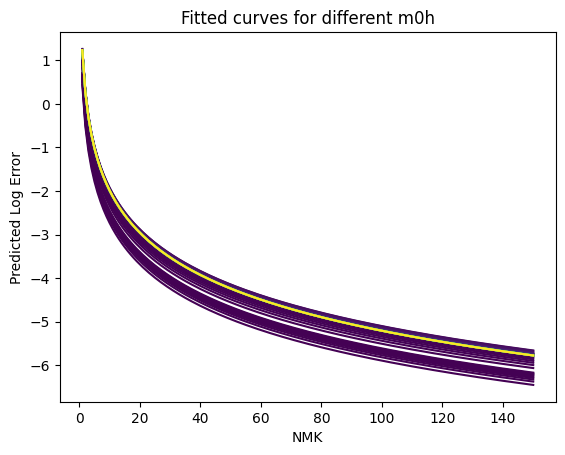

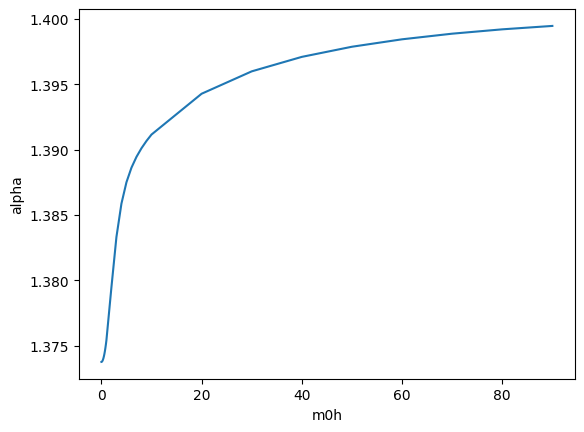

fitted slope: 0.000329, slope/avg: 0.000238


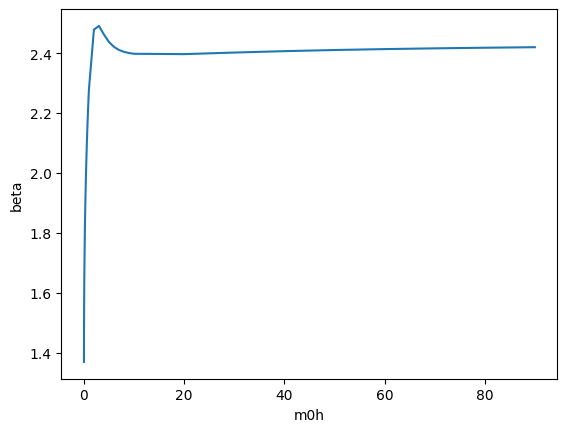

fitted slope: 0.00713, slope/avg: 0.0034


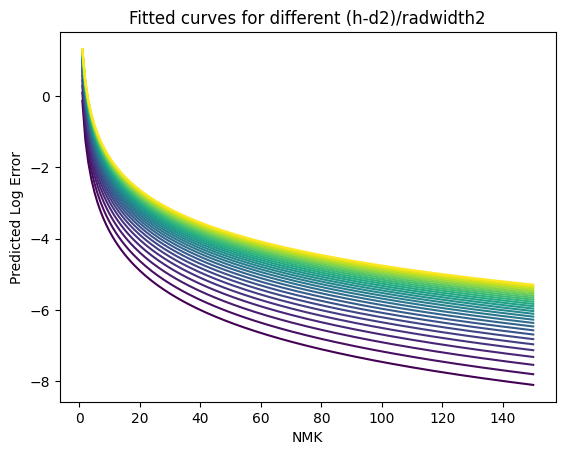

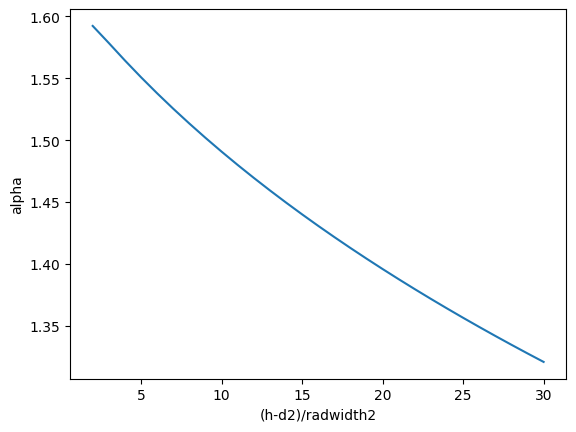

fitted slope: -0.0095, slope/avg: -0.0066


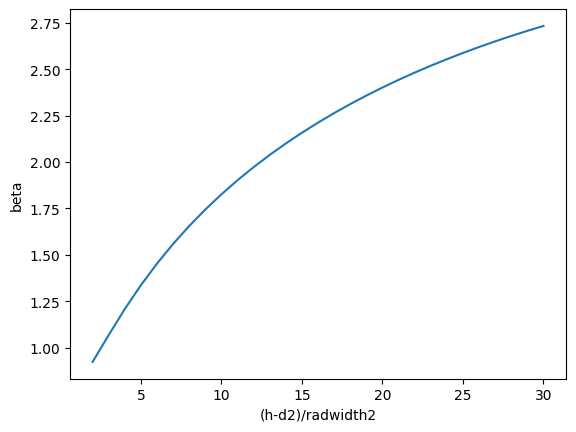

fitted slope: 0.0602, slope/avg: 0.0289


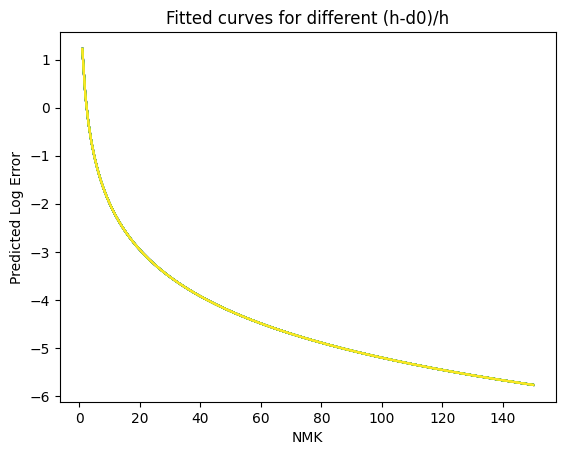

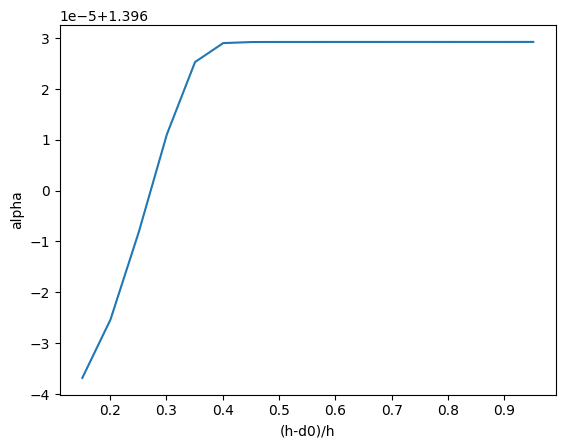

fitted slope: 6.09e-05, slope/avg: 4.36e-05


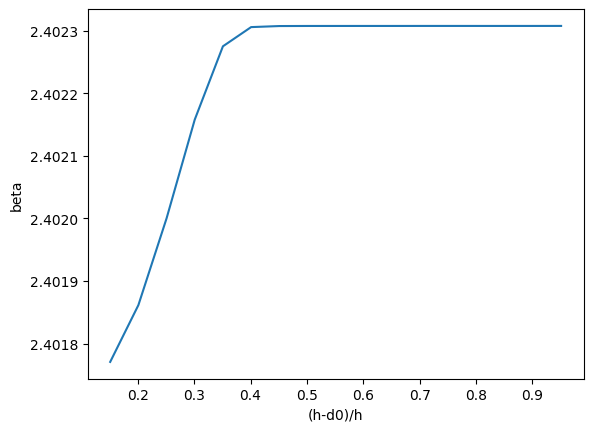

fitted slope: 0.000498, slope/avg: 0.000207


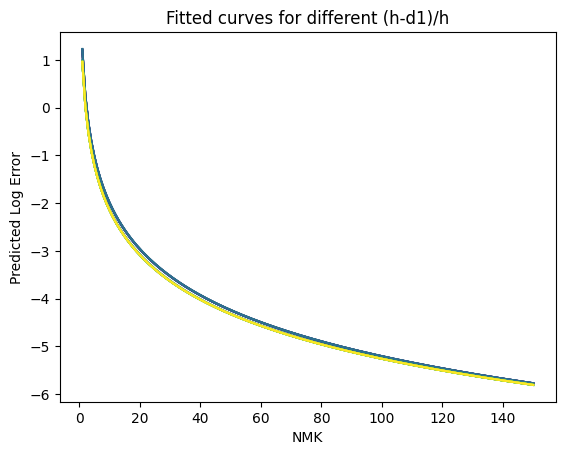

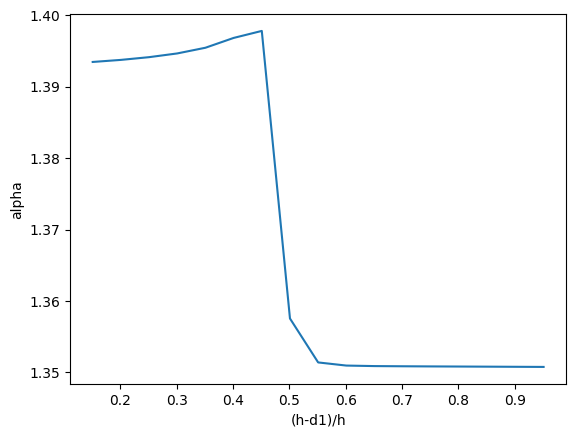

fitted slope: -0.0754, slope/avg: -0.055


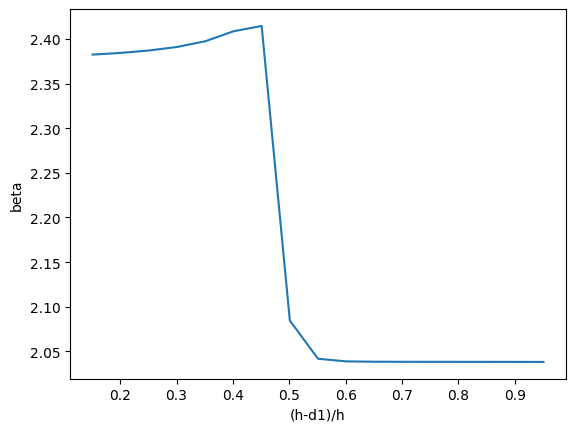

fitted slope: -0.607, slope/avg: -0.277


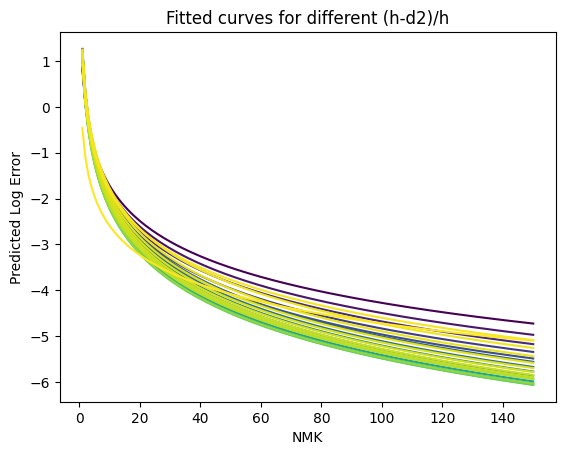

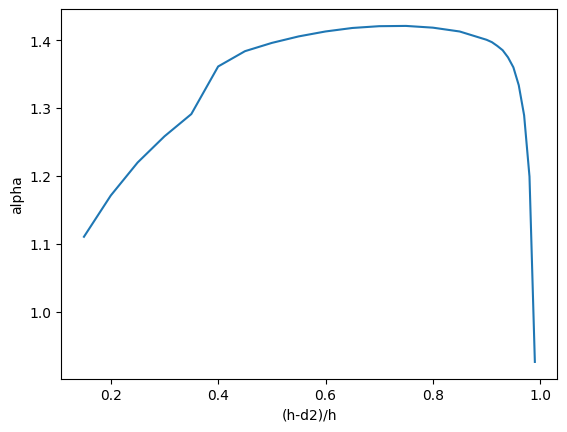

fitted slope: 0.0868, slope/avg: 0.0655


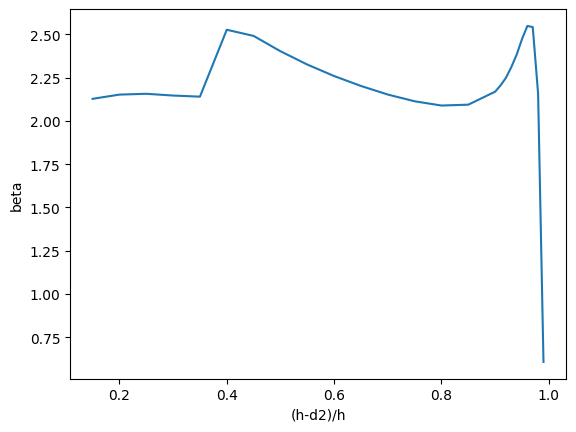

fitted slope: -0.152, slope/avg: -0.0693


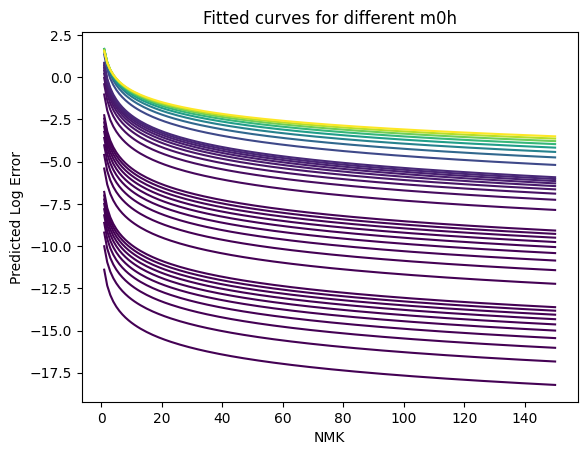

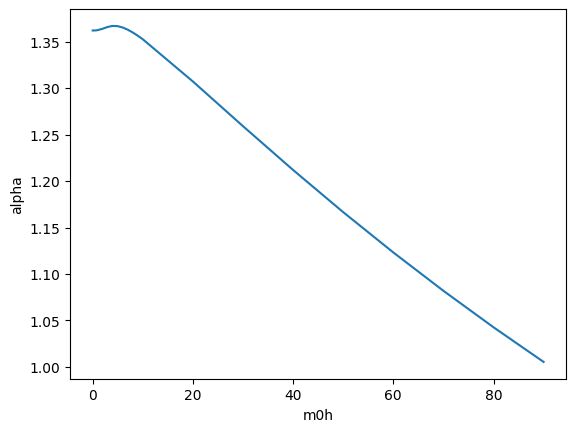

fitted slope: -0.00403, slope/avg: -0.00307


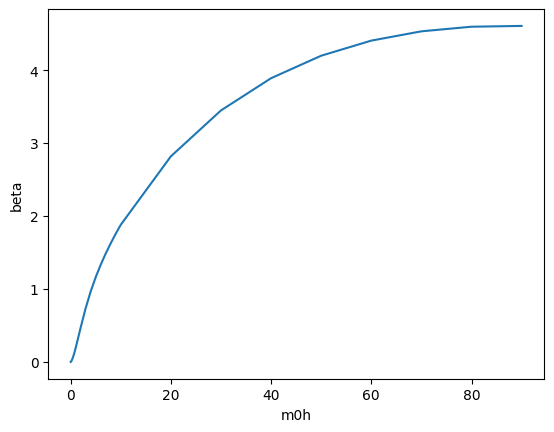

fitted slope: 0.0616, slope/avg: 0.0495


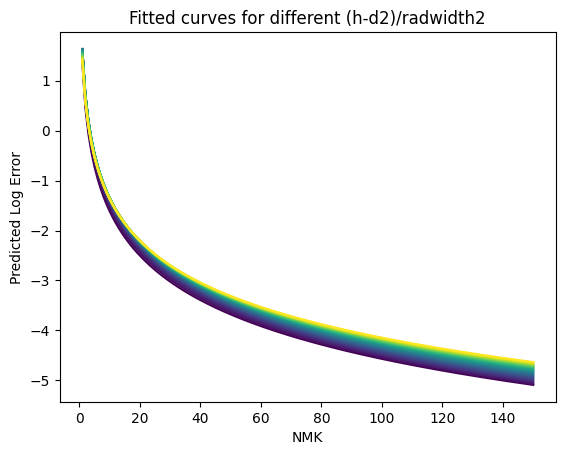

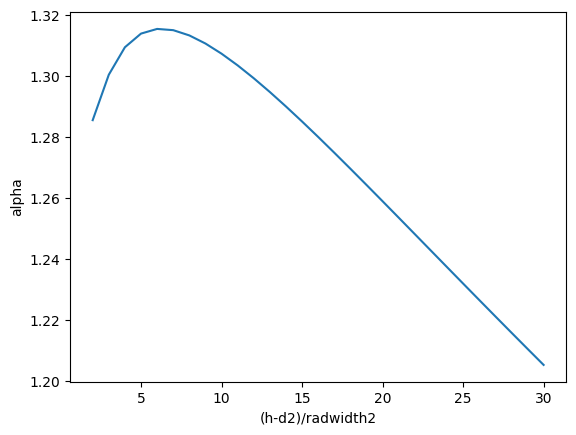

fitted slope: -0.00397, slope/avg: -0.00312


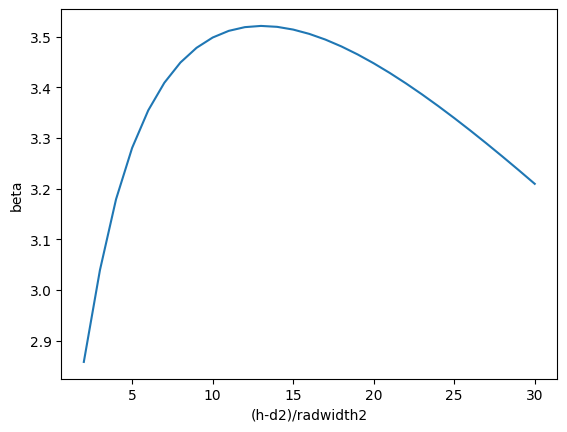

fitted slope: 0.00233, slope/avg: 0.000692


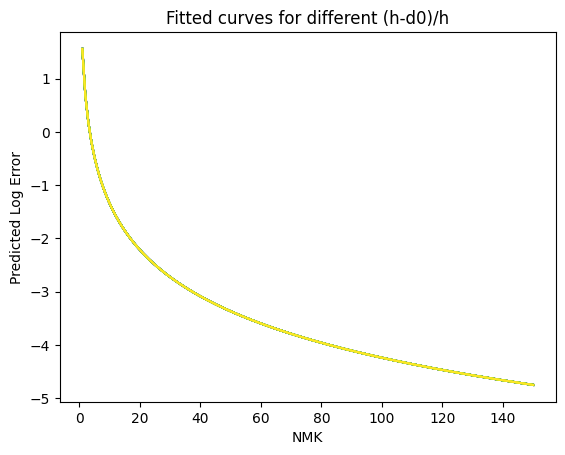

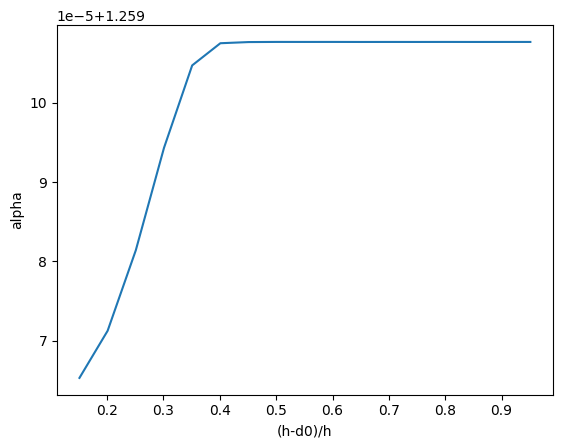

fitted slope: 4.07e-05, slope/avg: 3.23e-05


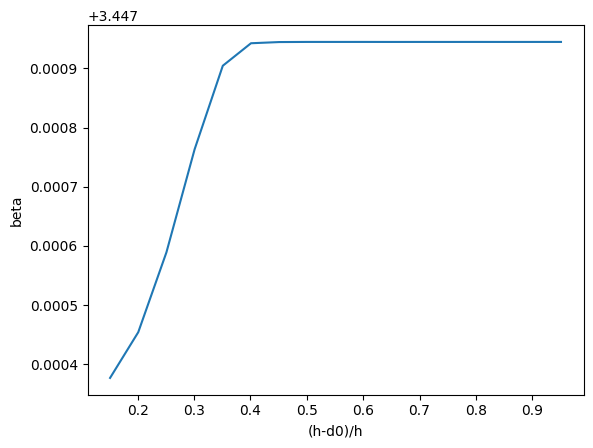

fitted slope: 0.000548, slope/avg: 0.000159


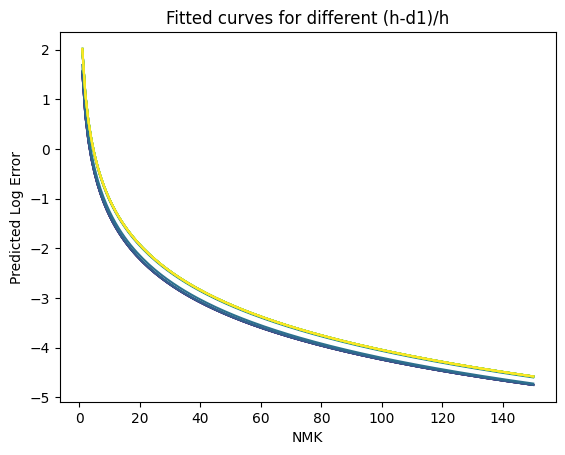

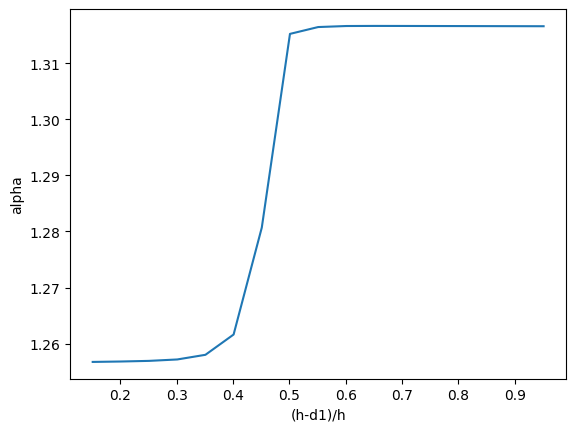

fitted slope: 0.0993, slope/avg: 0.0768


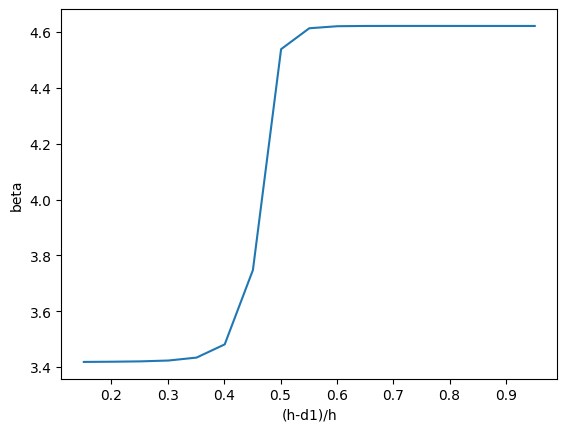

fitted slope: 2.02, slope/avg: 0.488


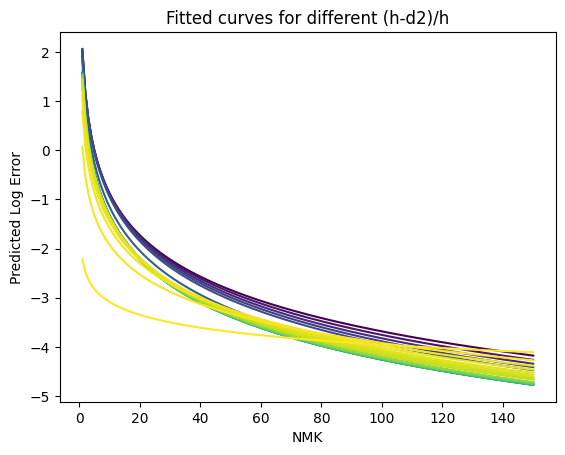

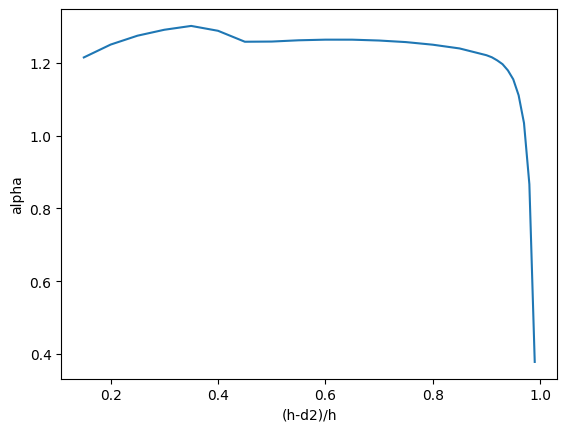

fitted slope: -0.325, slope/avg: -0.275


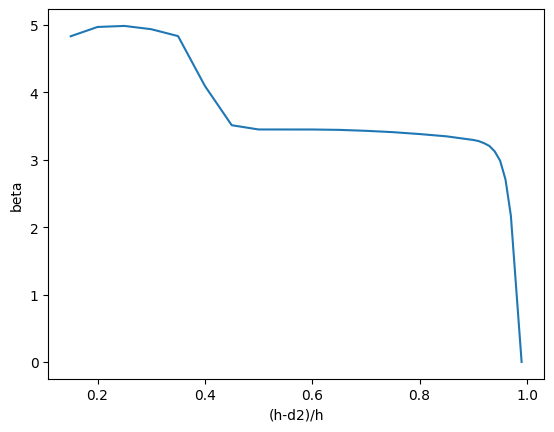

fitted slope: -3.23, slope/avg: -0.953


In [40]:
am_r2s = []
dp_r2s = []

for key in dimensionless_quantities.keys():
  info = dimensionless_quantities[key]
  pack = multi_fit_parameters(info[0], info[1], "am", sort_label = key,
                            local_maxima = False, plot_comparison = False,
                            print_params = False, plot_multi_log_comparison = True, plot_multi_params = True,
                            nmk_max = 150, linear_model = False, r2_lin = False, underweight = 1)
  am_r2s.append([pack[4], pack[5]])

for key in dimensionless_quantities.keys():
  info = dimensionless_quantities[key]
  pack = multi_fit_parameters(info[0], info[1], "dp", sort_label = key,
                            local_maxima = False, plot_comparison = False,
                            print_params = False, plot_multi_log_comparison = True, plot_multi_params = True,
                            nmk_max = 150, linear_model = False, r2_lin = False, underweight = 1)
  dp_r2s.append([pack[4], pack[5]])

In [41]:
dimensionless_quantities_2 = {"(total radius)/h set 1-1" : [all_prob_sets[6], fs["(total radius)/h"]],
                              "h/(total radius) set 1-1" : [all_prob_sets[6], fs["h/(total radius)"]],
                              # "(total radius)/h set 1-2" : [all_prob_sets[7], fs["(total radius)/h"]],
                              # "(total radius)/h set 1-3" : [all_prob_sets[8], fs["(total radius)/h"]],
                              # "(total radius)/h set 1-4" : [all_prob_sets[9], fs["(total radius)/h"]],
                              # "(total radius)/h set 1-5" : [all_prob_sets[10], fs["(total radius)/h"]],
                              # "(total radius)/h set 1-6" : [all_prob_sets[11], fs["(total radius)/h"]],
                              "radwidth2/(total radius) set 1-1" : [all_prob_sets[6], fs["radwidth2/(total radius)"]],
                              "(total radius)/radwidth2 set 1-1" : [all_prob_sets[6], fs["(total radius)/radwidth2"]],
                              "m0(total radius) set 1" : [[all_prob_sets[i][-1] for i in range(6, 12)], fs["m0(total radius)"]]}

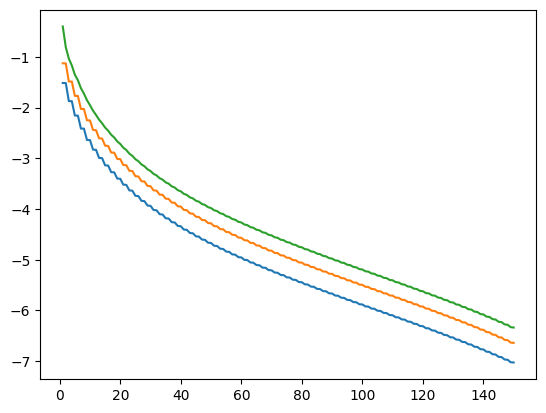

In [38]:
subdata = all_prob_sets[1]
plt.plot(list(range(1, 151)), subdata[0][subdata[0]["m0s"][0]]["log errors am"])
plt.plot(list(range(1, 151)), subdata[10][subdata[10]["m0s"][0]]["log errors am"])
plt.plot(list(range(1, 151)), subdata[-1][subdata[-1]["m0s"][0]]["log errors am"])

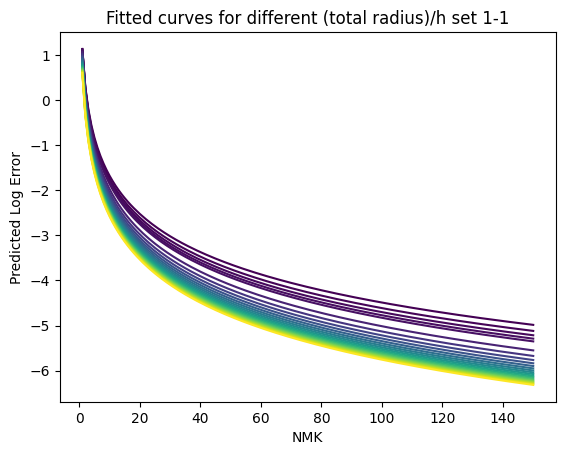

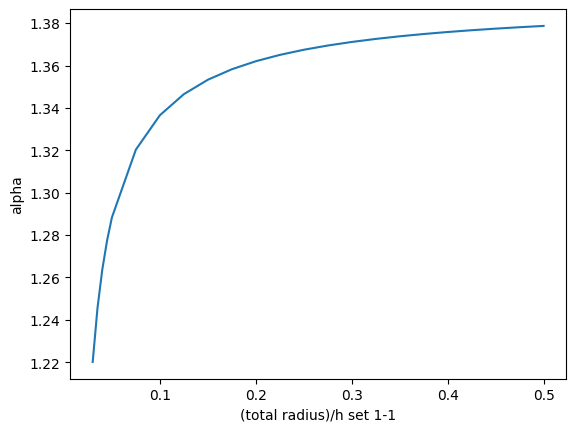

fitted slope: 0.249, slope/avg: 0.186


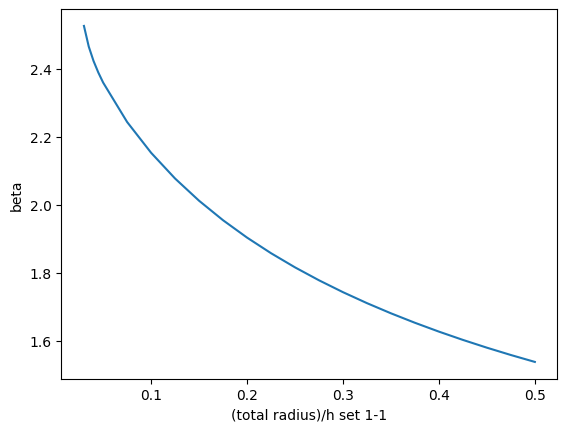

fitted slope: -1.99, slope/avg: -1.03


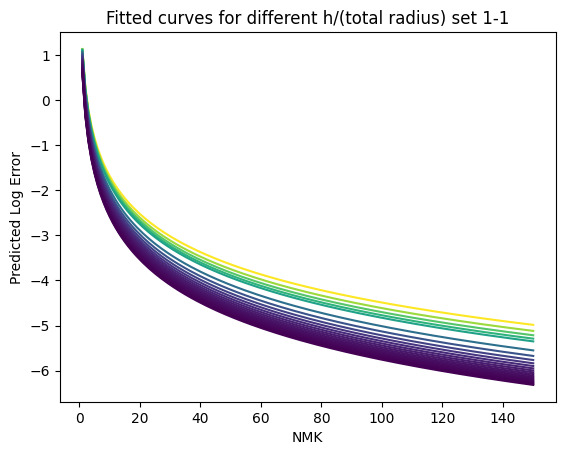

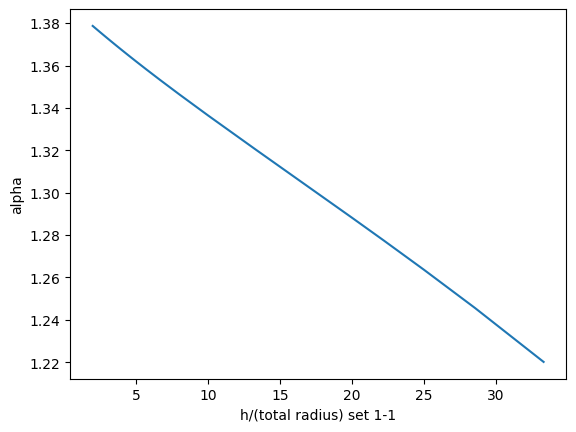

fitted slope: -0.005, slope/avg: -0.00373


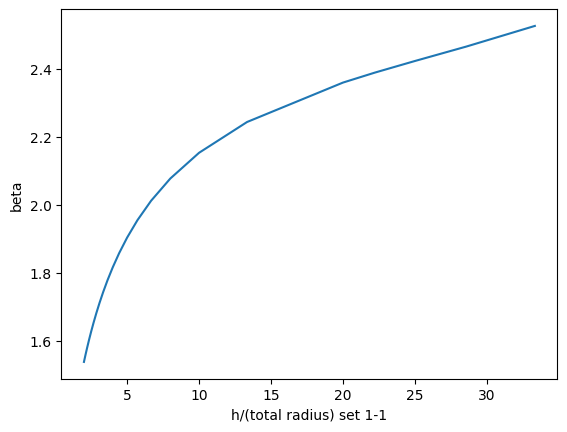

fitted slope: 0.0316, slope/avg: 0.0163


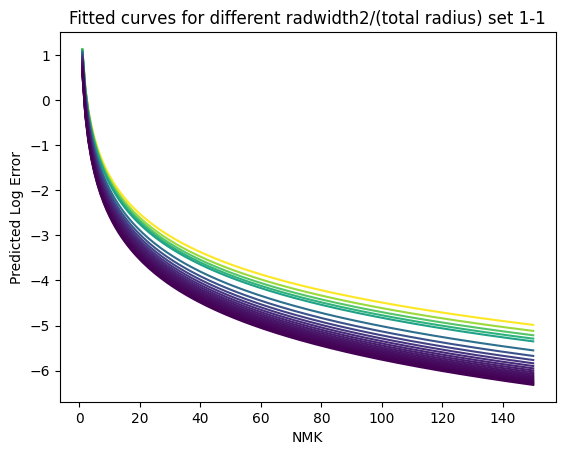

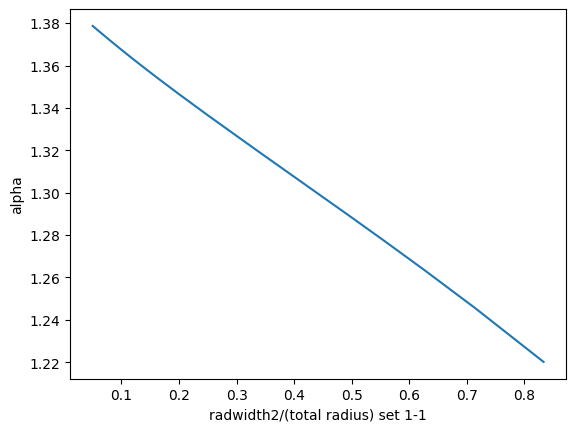

fitted slope: -0.2, slope/avg: -0.149


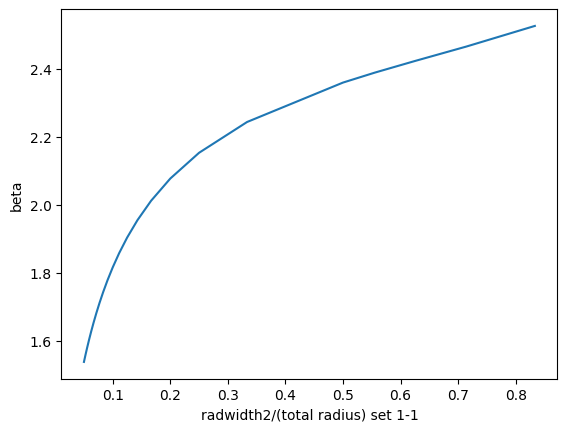

fitted slope: 1.26, slope/avg: 0.65


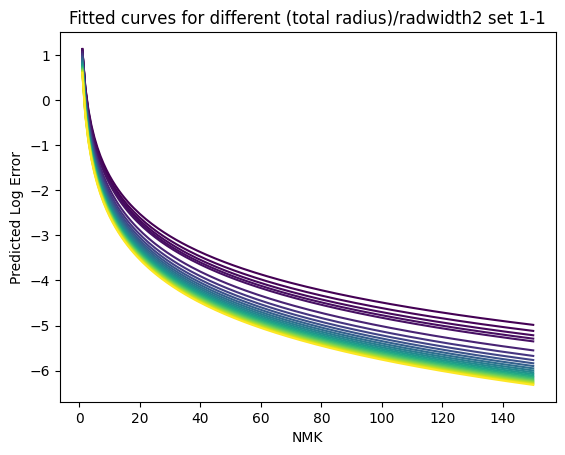

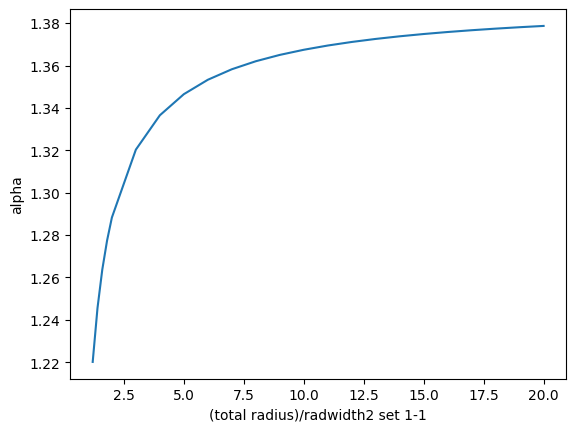

fitted slope: 0.00622, slope/avg: 0.00464


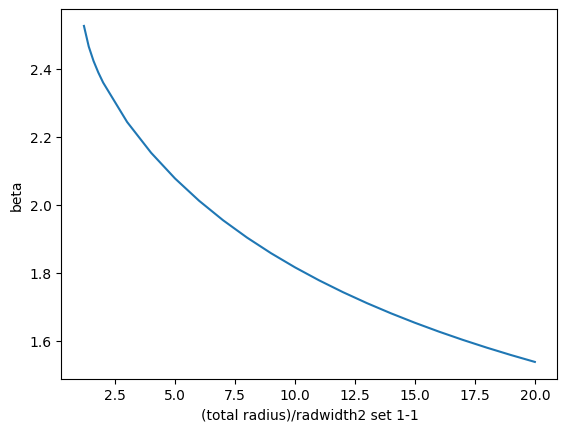

fitted slope: -0.0498, slope/avg: -0.0257


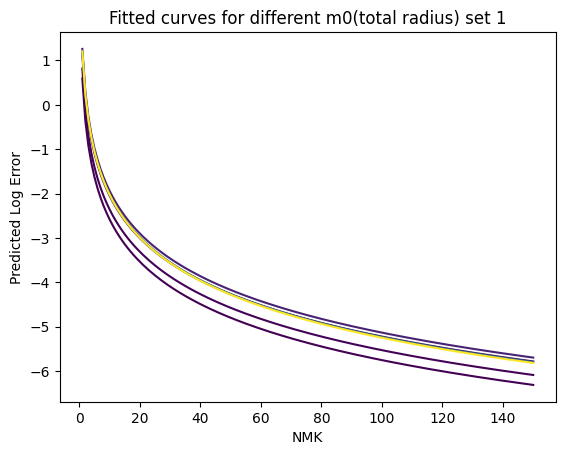

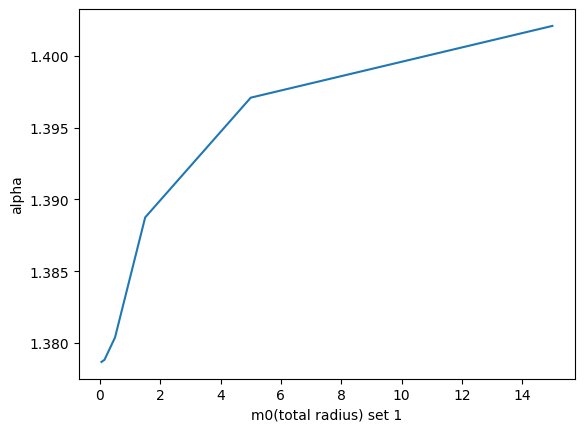

fitted slope: 0.00153, slope/avg: 0.0011


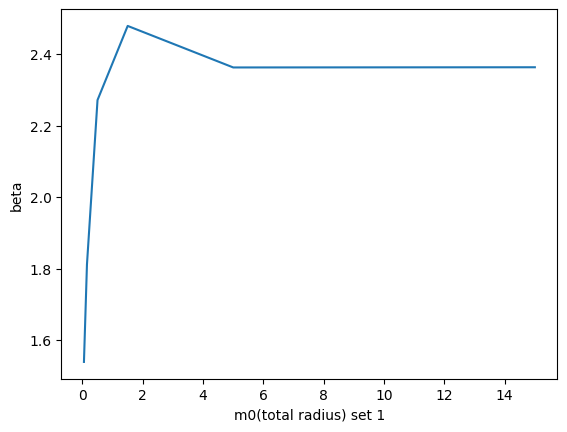

fitted slope: 0.0294, slope/avg: 0.0137


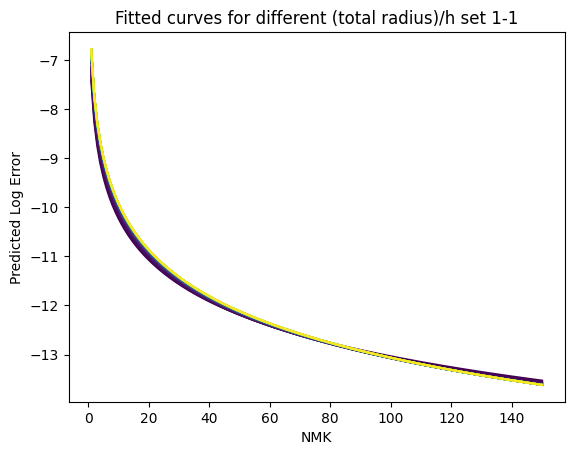

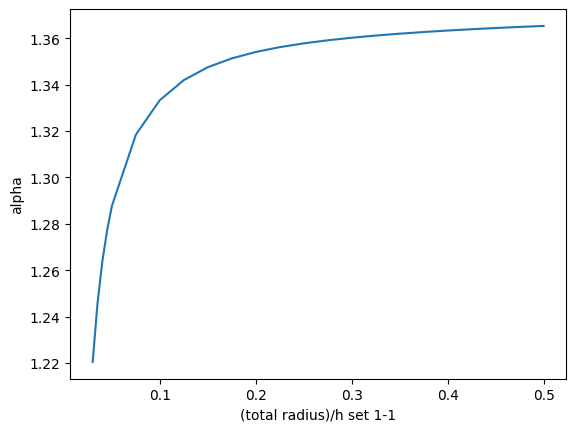

fitted slope: 0.218, slope/avg: 0.163


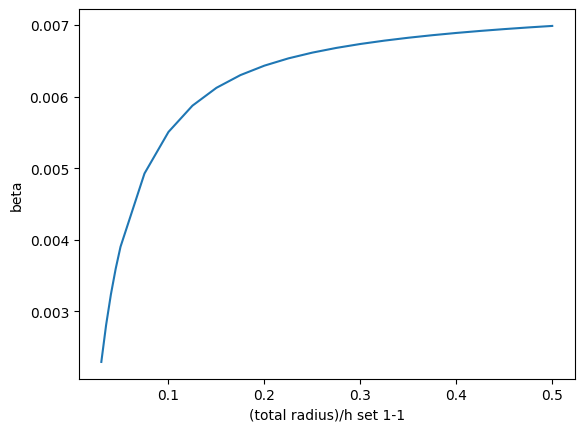

fitted slope: 0.00803, slope/avg: 1.39


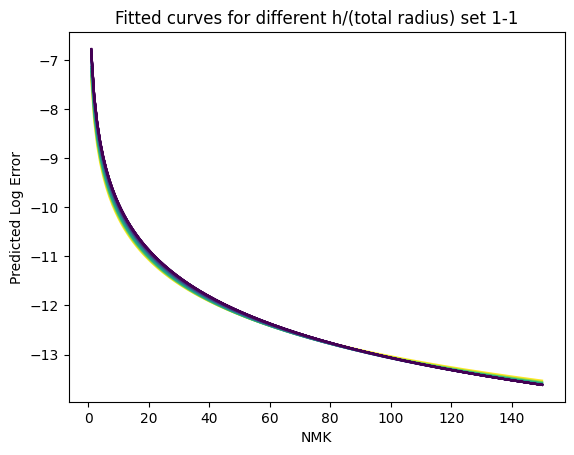

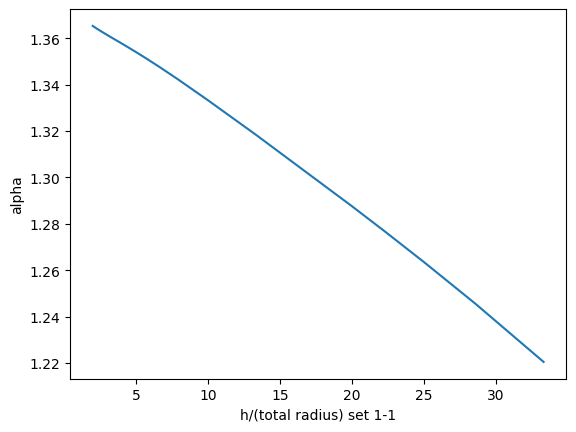

fitted slope: -0.00453, slope/avg: -0.00339


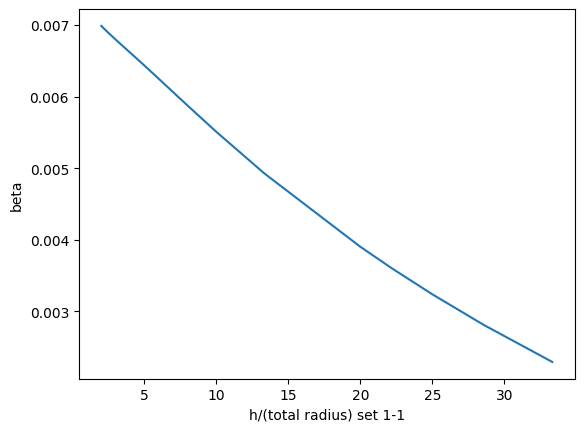

fitted slope: -0.000157, slope/avg: -0.0272


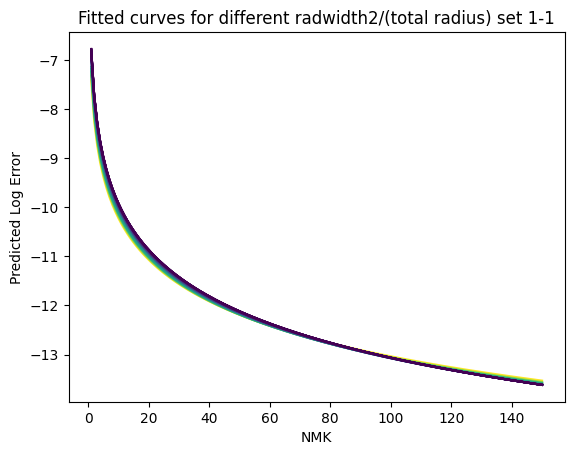

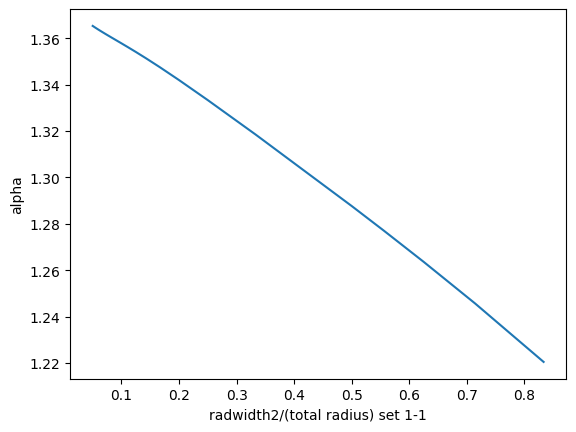

fitted slope: -0.181, slope/avg: -0.136


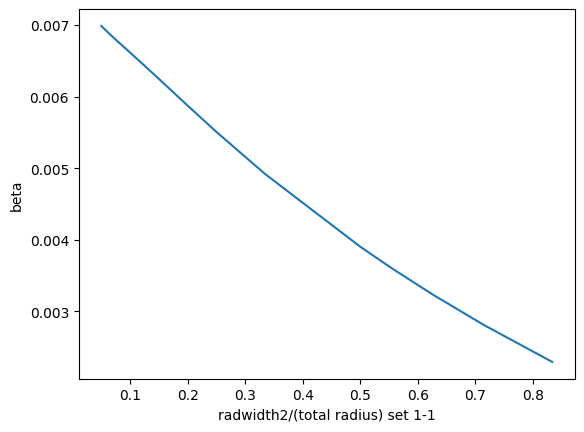

fitted slope: -0.00628, slope/avg: -1.09


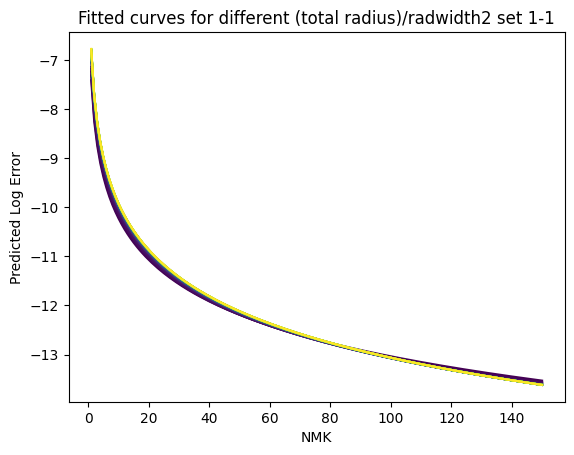

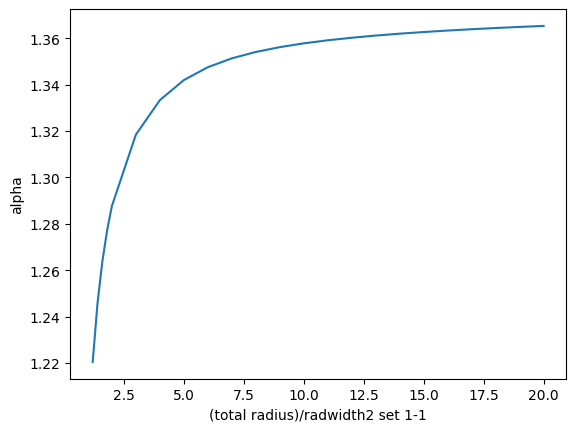

fitted slope: 0.00545, slope/avg: 0.00408


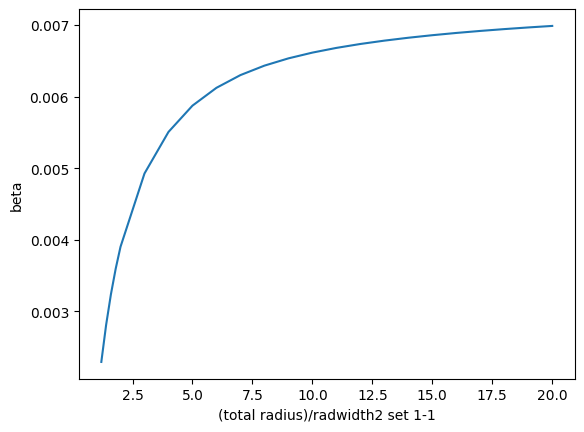

fitted slope: 0.000201, slope/avg: 0.0348


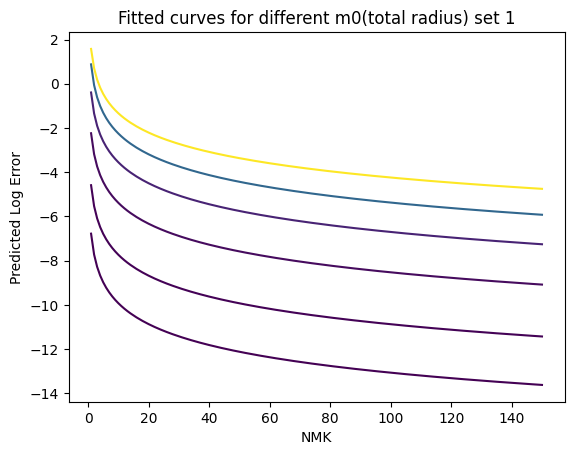

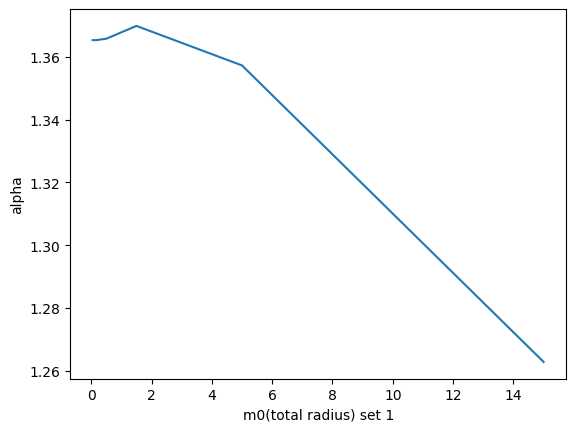

fitted slope: -0.00693, slope/avg: -0.00514


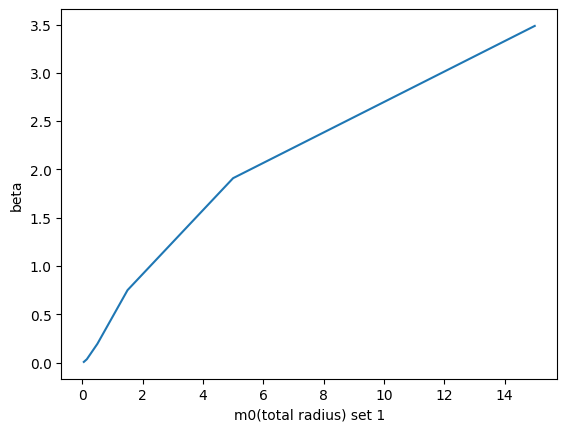

fitted slope: 0.232, slope/avg: 0.218


In [42]:
for key in dimensionless_quantities_2.keys():
  info = dimensionless_quantities_2[key]
  pack = multi_fit_parameters(info[0], info[1], "am", sort_label = key,
                            local_maxima = False, plot_comparison = False,
                            print_params = False, plot_multi_log_comparison = True, plot_multi_params = True,
                            nmk_max = 150, linear_model = False, r2_lin = False, underweight = 1)

for key in dimensionless_quantities_2.keys():
  info = dimensionless_quantities_2[key]
  pack = multi_fit_parameters(info[0], info[1], "dp", sort_label = key,
                            local_maxima = False, plot_comparison = False,
                            print_params = False, plot_multi_log_comparison = True, plot_multi_params = True,
                            nmk_max = 150, linear_model = False, r2_lin = False, underweight = 1)

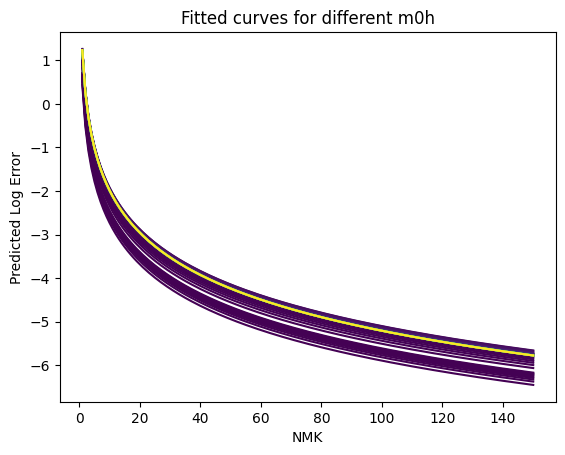

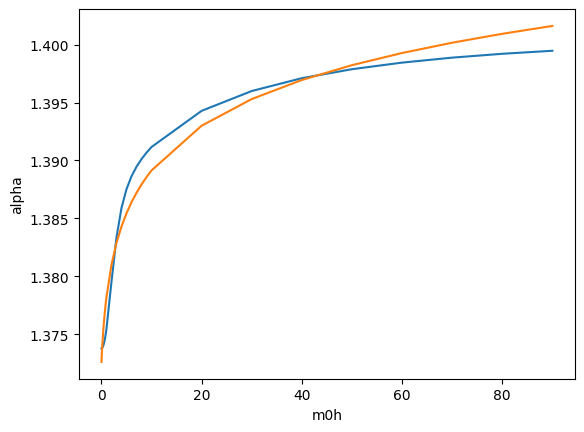

fitted slope: 0.000329, slope/avg: 0.000238


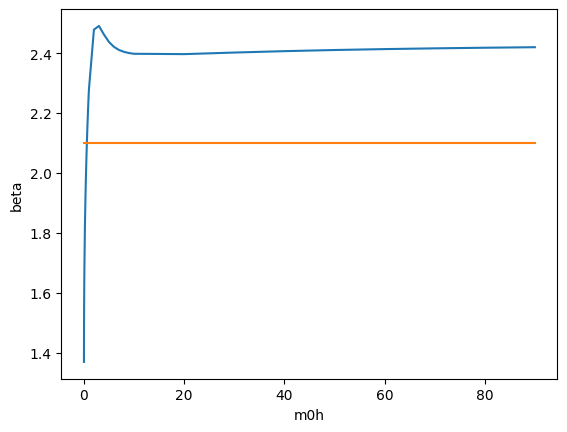

fitted slope: 0.00713, slope/avg: 0.0034


In [14]:
key = "m0h"
f1, f2 = lambda x, a, b, c : a * np.log(x + b) + c, lambda x, a : a
info = dimensionless_quantities[key]
pack = multi_fit_parameters(info[0], info[1], "am", sort_label = key, print_params = False,
                              multi_plot_fit_alpha = f1,
                              multi_plot_fit_beta = f2)